# Sentiment Analysis Project: App Reviews on Google Play Store

**Name:** Rashifa Ashri Nurrahim

**Email:** rashifa.nurrahim@gmail.com / b26b15a019@student.devacademy.id

**Dicoding ID:** b26b15a019

This project classifies the sentiment of app reviews into three classes: **negative, neutral, and positive**.
The reviews are written in Indonesian, so the class names in the code and outputs appear as
`negatif`, `netral`, and `positif`.

Workflow:
1. Load the self-scraped dataset (`dataset_ulasan.csv`)
2. Text preprocessing
3. Labeling with a lexicon-based approach (Indonesian sentiment dictionary)
4. Three training schemes

| Scheme | Algorithm | Feature extraction | Data split |
|---|---|---|---|
| 1 | BiLSTM (deep learning) | Word embedding | 80/20 |
| 2 | SVM | TF-IDF | 80/20 |
| 3 | Logistic Regression | Bag of Words | 70/30 |

5. Inference on new sentences
6. Error analysis of the misclassified reviews
7. Experiments with advanced preprocessing and data augmentation
8. Hyperparameter optimization with grid search
9. Model interpretability (feature weights, LIME) and visualization (word clouds, t-SNE)

## 1. Import libraries

In [1]:
import csv
import io
import re
import random

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

nltk.download("stopwords", quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 120)

## 2. Load the dataset

In [2]:
DATA_PATH = "dataset_ulasan.csv"

df = pd.read_csv(DATA_PATH)
print("Ukuran dataset:", df.shape)
df.info()

Ukuran dataset: (100000, 6)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   reviewId       100000 non-null  str  
 1   content        100000 non-null  str  
 2   score          100000 non-null  int64
 3   thumbsUpCount  100000 non-null  int64
 4   appVersion     77631 non-null   str  
 5   at             100000 non-null  str  
dtypes: int64(2), str(4)
memory usage: 4.6 MB


In [3]:
df.head()

,reviewId,content,score,thumbsUpCount,appVersion,at
0,7244bba7-bf14-4445-ad75-7361329f372b,tombol untuk ngirim foto di chat suka hilang sendiri butuh berkali-kali buka tutup aplikasi buat munculin lagi,1,0,5.77.1,2026-10-03 07:16:08
1,027608bc-1667-4478-910b-18d871803839,"top pokok e,terbaik di Indonesia",5,0,5.77.1,2026-10-03 06:53:36
2,f3dbb469-af6d-41f5-b612-a0299852a831,Cepat tanggap dan nyaman,5,0,5.77.1,2026-10-03 05:37:12
3,b7e04717-3911-4020-b8d7-0199bf96b013,good,5,0,5.77.1,2026-10-03 05:28:17
4,e8b62ee0-83dd-4ec2-b6c9-bd8c4f8e90b5,tolong orderan di aplikasi ini harus pakai KTP biar terlacak customer nya mesan serius atau main main merugikan driver,1,0,NaN,2026-10-03 05:17:57


In [4]:
# Buang baris tanpa isi ulasan dan ulasan yang persis sama
df = df.dropna(subset=["content"]).drop_duplicates(subset="content").reset_index(drop=True)
print("Jumlah ulasan setelah membuang nilai kosong dan duplikat:", len(df))

Jumlah ulasan setelah membuang nilai kosong dan duplikat: 69183


## 3. Text preprocessing

Steps:
1. **Cleaning and case folding**: lowercase the text and remove URLs, mentions, hashtags, numbers, punctuation, and emoji
2. **Slang normalization**: convert informal words to their standard form (`gk` becomes `tidak`, "not")
3. **Tokenization**: split sentences into words
4. **Stopword removal**: drop common words that carry no sentiment. Negation words such as `tidak` ("not") and `kurang` ("lacking") are deliberately kept because they affect sentiment.

In [5]:
KAMUS_SLANG = {
    "gk": "tidak", "ga": "tidak", "gak": "tidak", "g": "tidak", "ngga": "tidak", "nggak": "tidak",
    "enggak": "tidak", "engga": "tidak", "tdk": "tidak", "tak": "tidak", "kagak": "tidak", "kaga": "tidak",
    "gabisa": "tidak bisa", "gbs": "tidak bisa", "bgt": "sangat", "bngt": "sangat", "bgtt": "sangat",
    "yg": "yang", "dgn": "dengan", "dg": "dengan", "utk": "untuk", "u": "untuk", "krn": "karena",
    "karna": "karena", "krna": "karena", "jd": "jadi", "jdi": "jadi", "sy": "saya", "gw": "saya",
    "gue": "saya", "gua": "saya", "aq": "aku", "ak": "aku", "lu": "kamu", "lo": "kamu", "km": "kamu",
    "sdh": "sudah", "udh": "sudah", "udah": "sudah", "dah": "sudah", "blm": "belum", "blom": "belum",
    "tp": "tapi", "tpi": "tapi", "dr": "dari", "dri": "dari", "dlm": "dalam", "bs": "bisa", "bsa": "bisa",
    "aja": "saja", "aj": "saja", "sj": "saja", "jg": "juga", "jga": "juga", "lg": "lagi", "lgi": "lagi",
    "sm": "sama", "sma": "sama", "bkn": "bukan", "trs": "terus", "trus": "terus", "skrg": "sekarang",
    "skrng": "sekarang", "knp": "kenapa", "knapa": "kenapa", "gmn": "bagaimana", "gimana": "bagaimana",
    "bgs": "bagus", "bgus": "bagus", "mantul": "mantap", "mantab": "mantap", "mantep": "mantap",
    "ok": "oke", "oks": "oke", "okay": "oke", "thx": "terima kasih", "thanks": "terima kasih",
    "makasih": "terima kasih", "mksh": "terima kasih", "tq": "terima kasih", "trims": "terima kasih",
    "apk": "aplikasi", "app": "aplikasi", "apps": "aplikasi", "aplikasinya": "aplikasi",
    "lemot": "lambat", "lelet": "lambat", "ribet": "rumit", "eror": "error", "errror": "error",
    "banget": "sangat", "bener": "benar", "bner": "benar", "cepet": "cepat", "cpt": "cepat",
    "susah": "sulit", "gampang": "mudah", "tlg": "tolong",
    "dong": "", "sih": "", "nih": "", "deh": "",
    "kok": "", "ya": "", "yaa": "", "nya": "", "loh": "", "lah": "", "kan": "",
}

# Kata yang ada di daftar stopword NLTK tetapi membawa sentimen, jadi tidak dibuang
KATA_DIPERTAHANKAN = {
    "tidak", "bukan", "belum", "jangan", "kurang", "baik", "benar", "lama", "masalah", "sulit",
    "mudah", "cepat", "lambat", "bisa", "sangat", "sekali", "lebih", "paling", "terlalu", "cukup",
}

STOPWORDS = (set(stopwords.words("indonesian")) | set(stopwords.words("english"))) - KATA_DIPERTAHANKAN


def bersihkan_teks(teks):
    """Case folding dan penghapusan karakter selain huruf."""
    teks = str(teks).lower()
    teks = re.sub(r"https?://\S+|www\.\S+", " ", teks)   # URL
    teks = re.sub(r"[@#]\w+", " ", teks)                   # mention dan hashtag
    teks = re.sub(r"[^a-z\s]", " ", teks)                  # angka, tanda baca, emoji
    teks = re.sub(r"(.)\1{2,}", r"\1", teks)              # huruf berulang: "bagusss" -> "bagus"
    return re.sub(r"\s+", " ", teks).strip()


def normalisasi_slang(teks):
    """Mengganti kata tidak baku dengan padanan bakunya."""
    kata = [KAMUS_SLANG.get(k, k) for k in teks.split()]
    return " ".join(k for k in kata if k)


def tokenisasi(teks):
    return teks.split()


def hapus_stopword(tokens):
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]


def preprocess(teks):
    """Pipeline lengkap: teks mentah -> daftar token bersih."""
    return hapus_stopword(tokenisasi(normalisasi_slang(bersihkan_teks(teks))))

In [6]:
df["tokens"] = df["content"].apply(preprocess)
df["text_akhir"] = df["tokens"].apply(" ".join)

# Buang ulasan yang kosong setelah dibersihkan, lalu buang duplikat hasil preprocessing
# supaya tidak ada teks yang sama persis di data latih dan data uji
df = df[df["text_akhir"].str.len() > 0]
df = df.drop_duplicates(subset="text_akhir").reset_index(drop=True)

print("Jumlah ulasan siap pakai:", len(df))
df[["content", "text_akhir"]].head(10)

Jumlah ulasan siap pakai: 60500


,content,text_akhir
0,tombol untuk ngirim foto di chat suka hilang sendiri butuh berkali-kali buka tutup aplikasi buat munculin lagi,tombol ngirim foto chat suka hilang butuh berkali kali buka tutup aplikasi munculin
1,"top pokok e,terbaik di Indonesia",top pokok terbaik indonesia
2,Cepat tanggap dan nyaman,cepat tanggap nyaman
3,good,good
4,tolong orderan di aplikasi ini harus pakai KTP biar terlacak customer nya mesan serius atau main main merugikan driver,tolong orderan aplikasi pakai ktp biar terlacak customer mesan serius main main merugikan driver
5,respon cepat,respon cepat
6,Just for the system ok,system oke
7,"( aplikasi mafia ) pesen gofood bayar ongkos sudah mahal, pas tanya driver dapet upah berapa, jawaban driver hanya d...",aplikasi mafia pesen gofood bayar ongkos mahal pas driver dapet upah driver dapet ribu pantesan driver pilih pilih u...
8,makin kesini makin ngaco .. merugikan customer/resto untuk yg order hemat .. perluas aja denah argo Aceng nya biar p...,kesini ngaco merugikan customer resto order hemat perluas denah argo aceng biar jabotabek paling lama pindah kesebelah
9,"drivernya hama banget asli, hampir seluruh indonesia, driver ojol banyak melakukan pelanggaran lwn arah. lu tindak l...",drivernya hama sangat asli indonesia driver ojol pelanggaran lwn arah tindak kasih skors lawan arah biar tertib diem...


## 4. Lexicon-based labeling

Each word is matched against an Indonesian sentiment lexicon (InSet) that contains positive
and negative weights. The weights of all words in a review are summed into a score:

- score > 0 → **positive**
- score < 0 → **negative**
- score = 0 → **neutral**

In [7]:
URL_LEXICON_POSITIF = "https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv"
URL_LEXICON_NEGATIF = "https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv"


def muat_lexicon(url):
    """Mengunduh kamus sentimen berformat `kata,bobot` menjadi dictionary."""
    respons = requests.get(url, timeout=30)
    respons.raise_for_status()
    lexicon = {}
    for baris in csv.reader(io.StringIO(respons.text)):
        if len(baris) >= 2:
            try:
                lexicon[baris[0].strip()] = int(baris[1])
            except ValueError:
                continue
    return lexicon


lexicon_positif = muat_lexicon(URL_LEXICON_POSITIF)
lexicon_negatif = muat_lexicon(URL_LEXICON_NEGATIF)
print("Jumlah kata positif:", len(lexicon_positif))
print("Jumlah kata negatif:", len(lexicon_negatif))

Jumlah kata positif: 3609
Jumlah kata negatif: 6607


In [8]:
def hitung_skor(tokens):
    """Menjumlahkan bobot positif dan negatif dari semua kata."""
    return sum(lexicon_positif.get(t, 0) + lexicon_negatif.get(t, 0) for t in tokens)


def skor_ke_label(skor):
    if skor > 0:
        return "positif"
    if skor < 0:
        return "negatif"
    return "netral"


df["skor"] = df["tokens"].apply(hitung_skor)
df["label"] = df["skor"].apply(skor_ke_label)

print("Jumlah data :", len(df))
print(df["label"].value_counts())
assert len(df) >= 10_000, "Data kurang dari 10.000. Naikkan TARGET_ULASAN di notebook scraping."
df[["content", "text_akhir", "skor", "label"]].sample(10, random_state=SEED)

Jumlah data : 60500
label
negatif    37676
positif    16628
netral      6196
Name: count, dtype: int64


,content,text_akhir,skor,label
7947,"sangat bermanfaat, semoga pelayanan semakin baik ke depannya",sangat bermanfaat semoga pelayanan baik depannya,8,positif
28623,saya kasih bintang 1 karena alasan istri saya lama menunggu tidak dapat dapat gojek satupun kalian niat ngga sih car...,kasih bintang alasan istri lama menunggu tidak gojek satupun niat tidak cari ojek,-19,negatif
1554,ga bisa ngirim foto ke abang drivernya. buat apa ada fitur kamera sama file klo ga bisa dikirim,tidak bisa ngirim foto abang drivernya fitur kamera file klo tidak bisa dikirim,-5,negatif
23734,pesen gocar susah banget dapet driver nya pada jauh2 dan driver nya pada gak respon,pesen gocar sulit sangat dapet driver driver tidak respon,-3,negatif
21434,terlalu jauh kasih draiver,terlalu kasih draiver,-2,negatif
25387,byk promo,byk promo,3,positif
9618,Gojek membantu banyak pengangguran,gojek membantu pengangguran,-4,negatif
25045,"terimakasih,gocar,dan gojek bagus,mohon pertahankan,sy sebagai guru ASN pertahankan biaya gocar ya 32-35ribu dijam 1...",terimakasih gocar gojek bagus mohon pertahankan guru asn pertahankan biaya gocar ribu dijam sd wib pertahankan,9,positif
39272,Terimakasih atas bang gojek serta apk nya yaa. utamakan keselamatan dan kenyamanan penumpang. sukses selalu,terimakasih bang gojek aplikasi utamakan keselamatan kenyamanan penumpang sukses,5,positif
7678,sangat mudah pengunaannya. recomended banget deh,sangat mudah pengunaannya recomended sangat,-1,negatif


## 5. Exploratory data analysis

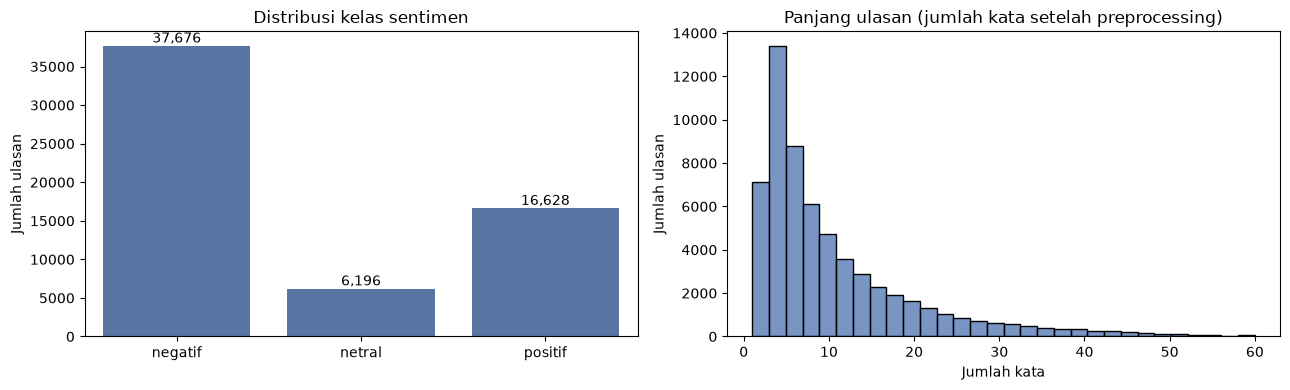

In [9]:
URUTAN_LABEL = ["negatif", "netral", "positif"]
df["jumlah_kata"] = df["tokens"].apply(len)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x="label", order=URUTAN_LABEL, ax=ax[0], color="#4C72B0")
ax[0].set_title("Distribusi kelas sentimen")
ax[0].set_xlabel("")
ax[0].set_ylabel("Jumlah ulasan")
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                   ha="center", va="bottom")

sns.histplot(df["jumlah_kata"].clip(upper=60), bins=30, ax=ax[1], color="#4C72B0")
ax[1].set_title("Panjang ulasan (jumlah kata setelah preprocessing)")
ax[1].set_xlabel("Jumlah kata")
ax[1].set_ylabel("Jumlah ulasan")
plt.tight_layout()
plt.show()

In [10]:
# Kata yang paling sering muncul di tiap kelas
for label in URUTAN_LABEL:
    kata = pd.Series([t for tokens in df.loc[df["label"] == label, "tokens"] for t in tokens])
    print(f"{label:8s}:", ", ".join(kata.value_counts().head(12).index))

negatif : tidak, driver, aplikasi, sangat, gojek, bisa, lama, jam, nunggu, tolong, gofood, sulit
netral  : gojek, driver, sangat, cepat, tidak, membantu, bisa, aplikasi, sulit, bagus, gofood, drivernya
positif : gojek, driver, sangat, mantap, lebih, baik, ramah, cepat, mudah, kasih, promo, bisa


## 6. Preparing the data for training

Labels are converted to integers, and a helper function is defined so that every scheme is evaluated the same way.

In [11]:
LABEL_KE_ID = {"negatif": 0, "netral": 1, "positif": 2}
ID_KE_LABEL = {v: k for k, v in LABEL_KE_ID.items()}

X = df["text_akhir"].values
y = df["label"].map(LABEL_KE_ID).values

hasil_skema = []


def evaluasi(nama, y_train, pred_train, y_test, pred_test):
    """Mencetak akurasi train/test, classification report, dan confusion matrix."""
    akurasi_train = accuracy_score(y_train, pred_train)
    akurasi_test = accuracy_score(y_test, pred_test)
    hasil_skema.append({"Skema": nama, "Akurasi train": akurasi_train, "Akurasi test": akurasi_test})

    print(f"{nama}")
    print(f"Akurasi train: {akurasi_train:.4f}")
    print(f"Akurasi test : {akurasi_test:.4f}\n")
    print(classification_report(y_test, pred_test, target_names=URUTAN_LABEL, digits=4))

    plt.figure(figsize=(4.5, 3.5))
    sns.heatmap(confusion_matrix(y_test, pred_test), annot=True, fmt="d", cmap="Blues",
                xticklabels=URUTAN_LABEL, yticklabels=URUTAN_LABEL)
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.title(f"Confusion matrix (test)")
    plt.tight_layout()
    plt.show()

## 7. Scheme 1: BiLSTM + Word Embedding (80/20)

- **Algorithm:** Bidirectional LSTM (deep learning)
- **Feature extraction:** text is converted into a sequence of word indices, then mapped to vectors by an `Embedding` layer that is trained together with the model
- **Data split:** 80% train, 20% test

In [12]:
import tensorflow as tf
from tensorflow.keras import callbacks, layers, models

tf.keras.utils.set_random_seed(SEED)

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

UKURAN_VOCAB = 20_000
PANJANG_MAKS = int(min(100, np.percentile(df["jumlah_kata"], 99)))
print("Panjang sekuens:", PANJANG_MAKS)

# Kamus kata hanya dibangun dari data latih agar tidak ada kebocoran informasi dari data uji
vectorizer_dl = layers.TextVectorization(
    max_tokens=UKURAN_VOCAB,
    standardize=None,                # teks sudah dibersihkan pada tahap preprocessing
    split="whitespace",
    output_mode="int",
    output_sequence_length=PANJANG_MAKS,
)
vectorizer_dl.adapt(tf.data.Dataset.from_tensor_slices(X_train_1.tolist()).batch(512))


def ke_sekuens(daftar_teks):
    """Mengubah daftar teks menjadi matriks indeks kata berukuran (n, PANJANG_MAKS)."""
    return vectorizer_dl(tf.constant(list(daftar_teks))).numpy()


X_train_seq = ke_sekuens(X_train_1)
X_test_seq = ke_sekuens(X_test_1)
print("Bentuk data latih:", X_train_seq.shape, "| data uji:", X_test_seq.shape)

Panjang sekuens: 47


Bentuk data latih: (48400, 47) | data uji: (12100, 47)


In [13]:
def bangun_bilstm(ukuran_vocab, panjang_maks, jumlah_kelas=3):
    masukan = layers.Input(shape=(panjang_maks,), dtype="int32")
    x = layers.Embedding(ukuran_vocab, 128)(masukan)
    x = layers.SpatialDropout1D(0.2)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.concatenate([layers.GlobalMaxPooling1D()(x), layers.GlobalAveragePooling1D()(x)])
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    keluaran = layers.Dense(jumlah_kelas, activation="softmax")(x)

    model = models.Model(masukan, keluaran)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


model_bilstm = bangun_bilstm(UKURAN_VOCAB, PANJANG_MAKS)
model_bilstm.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 47)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 47, 128)   │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 47, 128)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 47, 128)   │     98,816 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bidirectional[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ bidirectional[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,675,459 (10.21 MB)

 Trainable params: 2,675,459 (10.21 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Validasi diambil dari data latih, sehingga data uji tidak ikut menentukan kapan pelatihan berhenti
daftar_callback = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]

riwayat = model_bilstm.fit(
    X_train_seq, y_train_1,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    callbacks=daftar_callback,
    verbose=2,
)

Epoch 1/20


341/341 - 51s - 149ms/step - accuracy: 0.8431 - loss: 0.4138 - val_accuracy: 0.9289 - val_loss: 0.2074 - learning_rate: 0.0010


Epoch 2/20


341/341 - 33s - 98ms/step - accuracy: 0.9456 - loss: 0.1567 - val_accuracy: 0.9351 - val_loss: 0.1751 - learning_rate: 0.0010


Epoch 3/20


...

341/341 - 37s - 110ms/step - accuracy: 0.9966 - loss: 0.0149 - val_accuracy: 0.9490 - val_loss: 0.2688 - learning_rate: 1.2500e-04


Epoch 10/20


341/341 - 36s - 106ms/step - accuracy: 0.9972 - loss: 0.0135 - val_accuracy: 0.9483 - val_loss: 0.2865 - learning_rate: 1.2500e-04


Epoch 11/20


341/341 - 41s - 120ms/step - accuracy: 0.9979 - loss: 0.0114 - val_accuracy: 0.9486 - val_loss: 0.2899 - learning_rate: 6.2500e-05


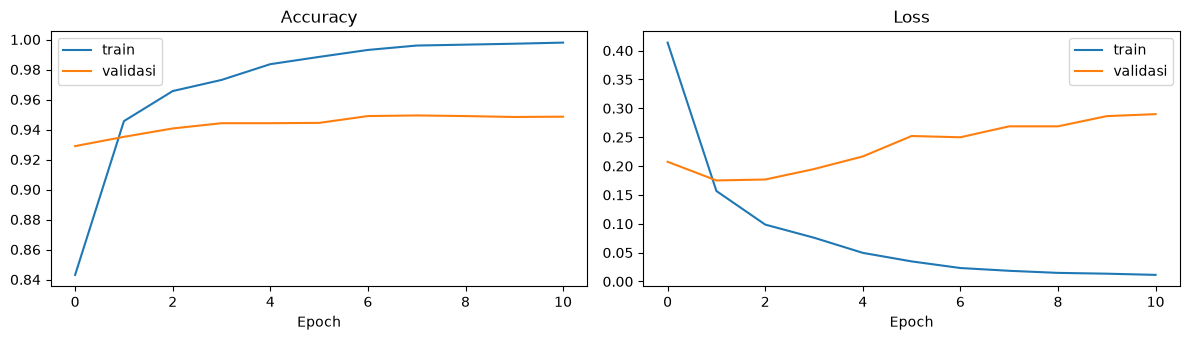

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for i, metrik in enumerate(["accuracy", "loss"]):
    ax[i].plot(riwayat.history[metrik], label="train")
    ax[i].plot(riwayat.history[f"val_{metrik}"], label="validasi")
    ax[i].set_title(metrik.capitalize())
    ax[i].set_xlabel("Epoch")
    ax[i].legend()
plt.tight_layout()
plt.show()

Skema 1: BiLSTM + Embedding (80/20)
Akurasi train: 0.9937
Akurasi test : 0.9494

              precision    recall  f1-score   support

     negatif     0.9737    0.9766    0.9752      7535
      netral     0.7625    0.8370    0.7980      1239
     positif     0.9717    0.9296    0.9502      3326

    accuracy                         0.9494     12100
   macro avg     0.9026    0.9144    0.9078     12100
weighted avg     0.9515    0.9494    0.9502     12100



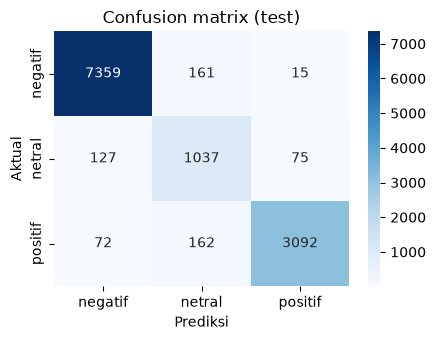

In [16]:
pred_train_1 = model_bilstm.predict(X_train_seq, batch_size=512, verbose=0).argmax(axis=1)
pred_test_1 = model_bilstm.predict(X_test_seq, batch_size=512, verbose=0).argmax(axis=1)

evaluasi("Skema 1: BiLSTM + Embedding (80/20)", y_train_1, pred_train_1, y_test_1, pred_test_1)

## 8. Scheme 2: SVM + TF-IDF (80/20)

- **Algorithm:** Support Vector Machine with a linear kernel
- **Feature extraction:** TF-IDF (word weights based on frequency and rarity)
- **Data split:** 80% train, 20% test

Jumlah fitur TF-IDF: 25165


Skema 2: SVM + TF-IDF (80/20)
Akurasi train: 0.9756
Akurasi test : 0.9333

              precision    recall  f1-score   support

     negatif     0.9489    0.9857    0.9669      7535
      netral     0.8617    0.5682    0.6848      1239
     positif     0.9149    0.9507    0.9325      3326

    accuracy                         0.9333     12100
   macro avg     0.9085    0.8349    0.8614     12100
weighted avg     0.9306    0.9333    0.9286     12100



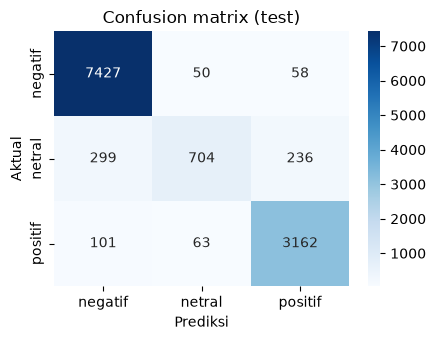

In [17]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

tfidf = TfidfVectorizer(token_pattern=r"\S+")
X_train_tfidf = tfidf.fit_transform(X_train_2)
X_test_tfidf = tfidf.transform(X_test_2)
print("Jumlah fitur TF-IDF:", X_train_tfidf.shape[1])

model_svm = LinearSVC(C=1.0, random_state=SEED)
model_svm.fit(X_train_tfidf, y_train_2)

evaluasi("Skema 2: SVM + TF-IDF (80/20)",
         y_train_2, model_svm.predict(X_train_tfidf),
         y_test_2, model_svm.predict(X_test_tfidf))

## 9. Scheme 3: Logistic Regression + Bag of Words (70/30)

- **Algorithm:** Logistic Regression
- **Feature extraction:** Bag of Words (word occurrence counts)
- **Data split:** 70% train, 30% test

Jumlah fitur Bag of Words: 23321


Skema 3: Logistic Regression + BoW (70/30)
Akurasi train: 0.9940
Akurasi test : 0.9417

              precision    recall  f1-score   support

     negatif     0.9684    0.9704    0.9694     11303
      netral     0.7861    0.7708    0.7784      1859
     positif     0.9380    0.9405    0.9392      4988

    accuracy                         0.9417     18150
   macro avg     0.8975    0.8939    0.8957     18150
weighted avg     0.9414    0.9417    0.9415     18150



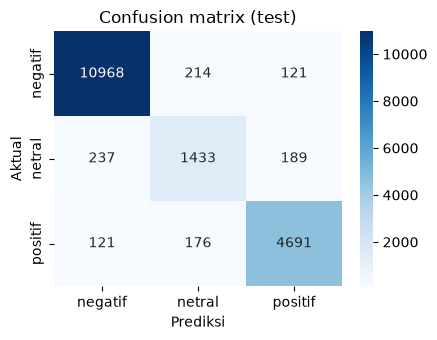

In [18]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

bow = CountVectorizer(token_pattern=r"\S+")
X_train_bow = bow.fit_transform(X_train_3)
X_test_bow = bow.transform(X_test_3)
print("Jumlah fitur Bag of Words:", X_train_bow.shape[1])

model_lr = LogisticRegression(C=10, max_iter=2000, random_state=SEED)
model_lr.fit(X_train_bow, y_train_3)

evaluasi("Skema 3: Logistic Regression + BoW (70/30)",
         y_train_3, model_lr.predict(X_train_bow),
         y_test_3, model_lr.predict(X_test_bow))

## 10. Comparison of the three schemes

In [19]:
ringkasan = pd.DataFrame(hasil_skema)
ringkasan["Train > 92%"] = ringkasan["Akurasi train"] > 0.92
ringkasan["Test > 92%"] = ringkasan["Akurasi test"] > 0.92
ringkasan["Test >= 85%"] = ringkasan["Akurasi test"] >= 0.85
ringkasan.style.format({"Akurasi train": "{:.2%}", "Akurasi test": "{:.2%}"})

,Skema,Akurasi train,Akurasi test,Train > 92%,Test > 92%,Test >= 85%
0,Skema 1: BiLSTM + Embedding (80/20),99.37%,94.94%,True,True,True
1,Skema 2: SVM + TF-IDF (80/20),97.56%,93.33%,True,True,True
2,Skema 3: Logistic Regression + BoW (70/30),99.40%,94.17%,True,True,True


## 11. Inference

The model is tried on new sentences that are not in the dataset. Each sentence goes through the same
preprocessing as the training data and is then predicted by the BiLSTM model. The output is a categorical class.

In [20]:
def prediksi_sentimen(daftar_teks):
    """Memprediksi sentimen kalimat baru dengan model BiLSTM."""
    teks_bersih = [" ".join(preprocess(t)) for t in daftar_teks]
    probabilitas = model_bilstm.predict(ke_sekuens(teks_bersih), verbose=0)
    return pd.DataFrame({
        "Teks": daftar_teks,
        "Prediksi": [ID_KE_LABEL[i] for i in probabilitas.argmax(axis=1)],
        "Keyakinan": probabilitas.max(axis=1).round(3),
    })


kalimat_uji = [
    "Aplikasinya bagus banget, sangat membantu dan mudah digunakan",
    "Pelayanannya cepat, driver ramah, saya puas sekali",
    "Aplikasi sering error dan lambat, sangat mengecewakan",
    "Saldo saya hilang, customer service tidak membantu sama sekali, parah",
    "Saya pesan jam tujuh pagi dari rumah ke kantor",
    "Update terbaru ukurannya 100 MB",
]

prediksi_sentimen(kalimat_uji)

,Teks,Prediksi,Keyakinan
0,"Aplikasinya bagus banget, sangat membantu dan mudah digunakan",negatif,1.000
1,"Pelayanannya cepat, driver ramah, saya puas sekali",positif,1.000
2,"Aplikasi sering error dan lambat, sangat mengecewakan",negatif,1.000
3,"Saldo saya hilang, customer service tidak membantu sama sekali, parah",negatif,1.000
4,Saya pesan jam tujuh pagi dari rumah ke kantor,netral,0.962
5,Update terbaru ukurannya 100 MB,positif,1.000


In [21]:
# Pembanding: prediksi kalimat yang sama oleh dua model klasik
teks_bersih = [" ".join(preprocess(t)) for t in kalimat_uji]
pd.DataFrame({
    "Teks": kalimat_uji,
    "SVM + TF-IDF": [ID_KE_LABEL[i] for i in model_svm.predict(tfidf.transform(teks_bersih))],
    "LogReg + BoW": [ID_KE_LABEL[i] for i in model_lr.predict(bow.transform(teks_bersih))],
})

,Teks,SVM + TF-IDF,LogReg + BoW
0,"Aplikasinya bagus banget, sangat membantu dan mudah digunakan",negatif,negatif
1,"Pelayanannya cepat, driver ramah, saya puas sekali",positif,positif
2,"Aplikasi sering error dan lambat, sangat mengecewakan",negatif,negatif
3,"Saldo saya hilang, customer service tidak membantu sama sekali, parah",negatif,negatif
4,Saya pesan jam tujuh pagi dari rumah ke kantor,negatif,negatif
5,Update terbaru ukurannya 100 MB,positif,positif


## 12. Error analysis

Accuracy alone does not show *where* a model fails. This section looks at the test reviews that the
BiLSTM (the model used for inference) classified incorrectly and checks which text patterns make an error more likely:
negation, contrast words, very short reviews, unseen words, emoji, and reviews whose lexicon score is close to zero.

In [22]:
# Rebuild the Scheme 1 test split by row index so each prediction can be traced back to its raw review
idx_train_1, idx_test_1 = train_test_split(np.arange(len(df)), test_size=0.2, random_state=SEED, stratify=y)
assert (X[idx_test_1] == X_test_1).all() and (y[idx_test_1] == y_test_1).all()

err = df.iloc[idx_test_1][["content", "text_akhir", "score", "skor", "jumlah_kata"]].copy()
err["actual"] = [ID_KE_LABEL[i] for i in y_test_1]
err["predicted"] = [ID_KE_LABEL[i] for i in pred_test_1]
err["wrong"] = err["actual"] != err["predicted"]

print(f"Misclassified by the BiLSTM: {err['wrong'].sum():,} of {len(err):,} test reviews ({err['wrong'].mean():.2%})")
print("\nMisclassified reviews, actual class (rows) vs predicted class (columns):")
pd.crosstab(err.loc[err["wrong"], "actual"], err.loc[err["wrong"], "predicted"]).reindex(
    index=URUTAN_LABEL, columns=URUTAN_LABEL, fill_value=0)

Misclassified by the BiLSTM: 612 of 12,100 test reviews (5.06%)

Misclassified reviews, actual class (rows) vs predicted class (columns):


predicted,negatif,netral,positif
actual,,,
negatif,0,161,15
netral,127,0,75
positif,72,162,0


In [23]:
POLA_NEGASI = r"\b(?:tidak|bukan|belum|jangan|kurang)\b"
POLA_KONTRAS = r"\b(?:tapi|tetapi|namun|padahal|cuma|sayangnya|walaupun|meskipun)\b"
POLA_EMOJI = "[\U0001F300-\U0001FAFF\u2600-\u27BF]"

# Contrast words are stopwords, so they are searched in the normalized text before stopword removal
teks_normal = err["content"].apply(lambda t: normalisasi_slang(bersihkan_teks(t)))
vocab_bilstm = set(vectorizer_dl.get_vocabulary())

err["has_negation"] = err["text_akhir"].str.contains(POLA_NEGASI)
err["has_contrast"] = teks_normal.str.contains(POLA_KONTRAS)
err["has_emoji"] = err["content"].str.contains(POLA_EMOJI)
err["has_unseen_word"] = err["text_akhir"].apply(lambda t: any(k not in vocab_bilstm for k in t.split()))
err["very_short"] = err["jumlah_kata"] <= 3
err["long"] = err["jumlah_kata"] > 30
err["score_near_zero"] = err["skor"].abs() <= 2

NAMA_POLA = {
    "has_negation": "Negation word (tidak, bukan, kurang, ...)",
    "has_contrast": "Contrast word (tapi, namun, padahal, ...)",
    "has_emoji": "Contains emoji",
    "has_unseen_word": "Word not in the BiLSTM vocabulary",
    "very_short": "Very short (3 tokens or fewer)",
    "long": "Long (more than 30 tokens)",
    "score_near_zero": "Lexicon score close to zero (|score| <= 2)",
}

baris = []
for kolom, nama in NAMA_POLA.items():
    ada = err[kolom]
    baris.append({
        "Pattern": nama,
        "Test reviews": int(ada.sum()),
        "Error rate with pattern": err.loc[ada, "wrong"].mean(),
        "Error rate without": err.loc[~ada, "wrong"].mean(),
    })
tabel_pola = pd.DataFrame(baris)
tabel_pola["Ratio"] = tabel_pola["Error rate with pattern"] / tabel_pola["Error rate without"]
tabel_pola.sort_values("Ratio", ascending=False).round(4).reset_index(drop=True)

,Pattern,Test reviews,Error rate with pattern,Error rate without,Ratio
0,Lexicon score close to zero (|score| <= 2),3552,0.1439,0.0118,12.1756
1,Word not in the BiLSTM vocabulary,2834,0.0663,0.0458,1.4497
2,Contains emoji,991,0.0585,0.0499,1.1736
3,"Contrast word (tapi, namun, padahal, ...)",2235,0.0492,0.0509,0.9672
4,Long (more than 30 tokens),674,0.0430,0.0510,0.8433
5,Very short (3 tokens or fewer),2968,0.0367,0.0551,0.6667
6,"Negation word (tidak, bukan, kurang, ...)",4528,0.0342,0.0604,0.5672


In [24]:
# Examples of misclassified reviews for the two riskiest text patterns
salah = err[err["wrong"]]
KOLOM_CONTOH = ["content", "actual", "predicted", "skor", "score"]

print("Misclassified reviews that contain a contrast word:")
display(salah[salah["has_contrast"]].sample(6, random_state=SEED)[KOLOM_CONTOH])

print("Misclassified reviews whose lexicon score is close to zero:")
display(salah[salah["score_near_zero"]].sample(6, random_state=SEED)[KOLOM_CONTOH])

Misclassified reviews that contain a contrast word:


,content,actual,predicted,skor,score
40486,sangat susah pakai fitur GopayPinjam padahal saya pengguna Gojek sejak usia 17 tahun sedangkan usia sy sekarang 23 w...,negatif,netral,-1,1
2970,"Pls lah, chat ke resto kalau bisa available 2 arah, bukan cuman restonya doang yang bisa ngechat kalau ada masalah. ...",netral,negatif,0,1
29113,saya udah top up. notifikasintransaksi sudah masuk.tp belum muncul di saldo gopay ka,positif,netral,2,2
40903,wkwkw akun ku di bekukan padahal cancel 5 kaki jarak nya juga jauh jauh semua,netral,negatif,0,1
30639,sakit banget di tipu tiap hari chek in agar dapet poin tapi setelah 6 hari chek in hari ke 7 nya yang seharusnya dap...,positif,negatif,2,1
39911,"gojek memang top, tapi tolong penghasilan driver terlalu kecil untuk hidup di Jkt.",positif,negatif,1,5


Misclassified reviews whose lexicon score is close to zero:


,content,actual,predicted,skor,score
52020,Terkadang eror kalo lagi bertransaksi,positif,netral,1,4
39758,enak recomen deh,positif,netral,1,5
55330,susah dapat driver kalau pesen gofood padahal sengaja gapake promo!,positif,negatif,1,1
36065,"Alamat rumah saya sering diteror seseorang dengan memesan makanan dalam jumlah banyak, saya tidak tahu bagaimana men...",positif,netral,2,3
38531,dari sekian banyaknya kendaraan apk ini satupun susah merespon,positif,negatif,2,1
9176,plis di tambah dana aku mau naik gojek tapi gak bisa bayar pake dana harus ovo atau gopay,positif,netral,1,4


### Checking the labels themselves

The models learn from lexicon labels, so a prediction that matches its label can still be wrong for a human reader.
Two checks: how often the lexicon label agrees with the star rating the user gave, and how the lexicon scores
the first inference sentence in section 11 (clearly positive, yet predicted `negatif` by all three models).

In [25]:
# Share of each lexicon label within each star-rating group
kelompok_rating = pd.cut(df["score"], [0, 2, 3, 5], labels=["1-2 stars", "3 stars", "4-5 stars"])
pd.crosstab(kelompok_rating, df["label"], normalize="index")[URUTAN_LABEL].round(3)

label,negatif,netral,positif
score,,,
1-2 stars,0.851,0.051,0.098
3 stars,0.777,0.072,0.150
4-5 stars,0.374,0.157,0.469


In [26]:
contoh = "Aplikasinya bagus banget, sangat membantu dan mudah digunakan"
bobot = pd.DataFrame([
    {"token": t, "positive weight": lexicon_positif.get(t, 0), "negative weight": lexicon_negatif.get(t, 0)}
    for t in preprocess(contoh)
])
bobot["total"] = bobot["positive weight"] + bobot["negative weight"]
print("Lexicon score:", bobot["total"].sum(), "->", skor_ke_label(bobot["total"].sum()))
bobot

Lexicon score: -7 -> negatif


,token,positive weight,negative weight,total
0,aplikasi,0,-4,-4
1,bagus,2,-4,-2
2,sangat,3,-5,-2
3,sangat,3,-5,-2
4,membantu,4,-4,0
5,mudah,4,-1,3


### Findings

- **Most errors involve the neutral class.** The BiLSTM misclassifies about 5% of the test reviews, and more than four out of five of those
  errors have `netral` as either the actual or the predicted class. Direct confusion between negative and positive is much rarer.
- **A lexicon score close to zero is by far the strongest warning sign.** Reviews with |score| <= 2 are misclassified about 14% of the time,
  against about 1.2% for the rest (roughly 12 times more often). These reviews sit on the border between classes, where a single word flips the label.
- **Unseen words raise the error rate by almost half; emoji only slightly.** Every word outside the 20,000-word vocabulary collapses into one
  "unknown" token, so slang and typos lose their meaning. The original preprocessing also deletes emoji.
- **Negation and contrast are not a weak point on this dataset.** Reviews with a negation word are misclassified about half as often as the others,
  and contrast words make almost no difference. A likely reason is that such reviews tend to be longer, clearly negative complaints.
- **Label quality is the larger limitation.** About 37% of 4-5 star reviews receive a `negatif` lexicon label, and about 10% of 1-2 star reviews
  receive `positif`. The inference sentence shows why: the lexicon gives `aplikasi` ("app") a weight of -4 and gives `bagus` ("good") and `sangat` ("very")
  a net negative weight, so a clearly positive sentence scores -7. The models reproduce the lexicon faithfully, including its mistakes.

The accuracy reported in this notebook therefore measures **agreement with the lexicon labels**, not agreement with human judgment.
The most valuable next step would be better labels (star ratings, a manually labeled sample, or a cleaned lexicon) rather than a larger model.

## 13. Advanced preprocessing and data augmentation

This section tests whether commonly recommended text-processing steps and data augmentation actually help on this dataset,
one change at a time. Every experiment uses the same model (SVM + TF-IDF from Scheme 2), the same 80/20 split, and the same labels,
so any change in the score comes from the text processing alone. The test set is never augmented.

| Experiment | What changes |
|---|---|
| Emoji handling | Emoji are converted into word tokens instead of being deleted |
| Negation handling | A negation word is merged with the word after it (`tidak bagus` becomes `tidak_bagus`) |
| Stemming | Frequent words are reduced to their root form with the Sastrawi stemmer |
| Augmentation | Extra training samples for the minority class (neutral) via synonym replacement, random insertion, and random swap |

In [27]:
%pip install -q Sastrawi lime wordcloud

Note: you may need to restart the kernel to use updated packages.


In [28]:
import unicodedata

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.metrics import f1_score, recall_score

NEGASI = {"tidak", "bukan", "belum", "jangan", "kurang"}

# Sastrawi needs about 0.1 second for every word that is not in its dictionary (slang, typos, brand names),
# so stemming all unique words would take far too long. Only the most frequent words are stemmed.
JUMLAH_KATA_DISTEM = 2000
stemmer = StemmerFactory().create_stemmer()
frekuensi_kata = pd.Series([t for tokens in df["tokens"] for t in tokens]).value_counts()
peta_stem = {kata: stemmer.stem(kata) for kata in frekuensi_kata.index[:JUMLAH_KATA_DISTEM]}
print(f"Stemmed the {JUMLAH_KATA_DISTEM:,} most frequent words, "
      f"covering {frekuensi_kata.iloc[:JUMLAH_KATA_DISTEM].sum() / frekuensi_kata.sum():.1%} of all tokens; "
      f"{sum(k != v for k, v in peta_stem.items()):,} of them changed\n")


def emoji_ke_token(teks):
    """Replace each emoji with a word token built from its Unicode name, e.g. 😡 -> emojipoutingface."""
    def ganti(m):
        nama = re.sub(r"[^a-z]", "", unicodedata.name(m.group(), "").lower())
        return f" emoji{nama} " if nama else " "
    return re.sub(POLA_EMOJI, ganti, str(teks))


def gabung_negasi(tokens):
    """Merge a negation word with the next token so the pair becomes one feature."""
    hasil, i = [], 0
    while i < len(tokens):
        if tokens[i] in NEGASI and i + 1 < len(tokens):
            hasil.append(tokens[i] + "_" + tokens[i + 1])
            i += 2
        else:
            hasil.append(tokens[i])
            i += 1
    return hasil


def preprocess_v2(teks, emoji=False, negasi=False, stem=False):
    """Original pipeline plus optional emoji handling, stemming, and negation merging."""
    if emoji:
        teks = emoji_ke_token(teks)
    tokens = preprocess(teks)
    if stem:
        tokens = [peta_stem.get(t, t) for t in tokens]
    if negasi:
        tokens = gabung_negasi(tokens)
    return " ".join(tokens)


contoh = "Drivernya tidak ramah 😡 tapi makanannya enak bgt 👍"
print("Original pipeline :", " ".join(preprocess(contoh)))
print("Emoji + negation  :", preprocess_v2(contoh, emoji=True, negasi=True))
print("With stemming     :", preprocess_v2(contoh, emoji=True, negasi=True, stem=True))

Stemmed the 2,000 most frequent words, covering 87.2% of all tokens; 533 of them changed

Original pipeline : drivernya tidak ramah makanannya enak sangat
Emoji + negation  : drivernya tidak_ramah emojipoutingface makanannya enak sangat emojithumbsupsign
With stemming     : drivernya tidak_ramah emojipoutingface makan enak sangat emojithumbsupsign


In [29]:
VARIAN = {
    "Baseline (original preprocessing)": {},
    "+ emoji tokens": {"emoji": True},
    "+ negation merging": {"negasi": True},
    "+ stemming": {"stem": True},
    "+ emoji + negation": {"emoji": True, "negasi": True},
}

teks_varian = {
    nama: df["content"].apply(lambda t: preprocess_v2(t, **opsi)).values
    for nama, opsi in VARIAN.items()
}
assert (teks_varian["Baseline (original preprocessing)"] == X).all()

In [30]:
def uji_svm(teks_latih, label_latih, teks_uji, label_uji):
    """Train the Scheme 2 model (TF-IDF + LinearSVC) and return its test metrics."""
    vektor = TfidfVectorizer(token_pattern=r"\S+")
    model = LinearSVC(C=1.0, random_state=SEED).fit(vektor.fit_transform(teks_latih), label_latih)
    pred = model.predict(vektor.transform(teks_uji))
    return {
        "Features": len(vektor.vocabulary_),
        "Accuracy": accuracy_score(label_uji, pred),
        "Macro F1": f1_score(label_uji, pred, average="macro"),
        "Neutral recall": recall_score(label_uji, pred, labels=[LABEL_KE_ID["netral"]], average=None)[0],
    }


hasil_prep = []
for nama, teks in teks_varian.items():
    hasil_prep.append({"Experiment": nama, **uji_svm(teks[idx_train_1], y[idx_train_1], teks[idx_test_1], y[idx_test_1])})
pd.DataFrame(hasil_prep).round(4)

,Experiment,Features,Accuracy,Macro F1,Neutral recall
0,Baseline (original preprocessing),25165,0.9333,0.8614,0.5682
1,+ emoji tokens,25435,0.9323,0.8597,0.5666
2,+ negation merging,29458,0.9119,0.8294,0.5077
3,+ stemming,24702,0.8988,0.8094,0.4794
4,+ emoji + negation,29753,0.9103,0.8266,0.5036


### Augmentation of the minority class

Neutral reviews are the smallest class and the one every model handles worst. New neutral training samples are generated with
three simple operations: **synonym replacement**, **random insertion** of a synonym, and **random swap** of two words.

Because the labels come from a lexicon, replacing a word can change the lexicon score and silently turn a neutral review
into a positive or negative one. Each augmented text is therefore re-scored, and it is kept only if its label is still neutral.

Back-translation is not used here: it needs an external translation model or API for tens of thousands of reviews, which would
make the notebook slow and hard to reproduce.

In [31]:
SINONIM = {
    "driver": ["pengemudi", "sopir"], "pengemudi": ["driver", "sopir"], "aplikasi": ["apk", "app"],
    "pesanan": ["orderan", "order"], "pesan": ["order"], "makanan": ["makan"], "promo": ["diskon"],
    "diskon": ["promo"], "harga": ["tarif", "biaya"], "tarif": ["harga", "biaya"], "ongkir": ["ongkos"],
    "lama": ["lambat"], "cepat": ["kilat"], "bagus": ["baik", "mantap"], "mantap": ["bagus", "keren"],
    "jelek": ["buruk"], "mahal": ["kemahalan"], "mudah": ["praktis"], "sulit": ["rumit"],
    "membantu": ["menolong"], "saldo": ["dana"], "akun": ["account"], "pelayanan": ["layanan", "servis"],
    "layanan": ["pelayanan", "servis"], "nunggu": ["menunggu"], "tolong": ["mohon"], "selalu": ["terus"],
}


def augmentasi(tokens, rng):
    """Apply one random operation: synonym replacement, random insertion, or random swap."""
    tokens = list(tokens)
    bisa_diganti = [i for i, t in enumerate(tokens) if t in SINONIM]
    operasi = rng.choice(["ganti", "sisip", "tukar"])
    if operasi == "ganti" and bisa_diganti:
        i = rng.choice(bisa_diganti)
        tokens[i] = rng.choice(SINONIM[tokens[i]])
    elif operasi == "sisip" and bisa_diganti:
        i = rng.choice(bisa_diganti)
        tokens.insert(rng.randrange(len(tokens) + 1), rng.choice(SINONIM[tokens[i]]))
    elif len(tokens) >= 2:
        i, j = rng.sample(range(len(tokens)), 2)
        tokens[i], tokens[j] = tokens[j], tokens[i]
    return tokens


rng = random.Random(SEED)
teks_latih = X[idx_train_1]
label_latih = y[idx_train_1]
sudah_ada = set(teks_latih)

teks_baru, dibuat = [], 0
for teks in teks_latih[label_latih == LABEL_KE_ID["netral"]]:
    for _ in range(2):                                   # two attempts per neutral review
        tokens = augmentasi(teks.split(), rng)
        hasil = " ".join(tokens)
        dibuat += 1
        # keep only new texts whose lexicon label is still neutral
        if hasil not in sudah_ada and skor_ke_label(hitung_skor(tokens)) == "netral":
            sudah_ada.add(hasil)
            teks_baru.append(hasil)

print(f"Neutral training reviews : {(label_latih == LABEL_KE_ID['netral']).sum():,}")
print(f"Augmented texts generated: {dibuat:,}")
print(f"Kept after the label check: {len(teks_baru):,}")
print("\nExample:")
print("  original :", teks_latih[label_latih == LABEL_KE_ID["netral"]][0])
print("  augmented:", teks_baru[0])

teks_latih_aug = np.concatenate([teks_latih, np.array(teks_baru, dtype=object)])
label_latih_aug = np.concatenate([label_latih, np.full(len(teks_baru), LABEL_KE_ID["netral"])])

hasil_aug = [
    {"Experiment": "Baseline (no augmentation)", "Train size": len(teks_latih),
     **uji_svm(teks_latih, label_latih, X[idx_test_1], y[idx_test_1])},
    {"Experiment": "+ neutral-class augmentation", "Train size": len(teks_latih_aug),
     **uji_svm(teks_latih_aug, label_latih_aug, X[idx_test_1], y[idx_test_1])},
]
pd.DataFrame(hasil_aug).round(4)

Neutral training reviews : 4,957
Augmented texts generated: 9,914
Kept after the label check: 5,071

Example:
  original : keren bagus oke
  augmented: oke bagus keren


,Experiment,Train size,Features,Accuracy,Macro F1,Neutral recall
0,Baseline (no augmentation),48400,25165,0.9333,0.8614,0.5682
1,+ neutral-class augmentation,53471,25167,0.9304,0.8650,0.6546


### Findings

- **None of the preprocessing changes improved the model.** Emoji tokens left the scores practically unchanged, negation merging lowered accuracy
  by about 2 points, and stemming lowered it by about 3.5 points.
- **The reason is the labeling method.** Lexicon labels are computed from individual, unstemmed words. Merging `tidak` with the next word, or
  reducing a word to its root, hides exactly the tokens the labeling rule used. With human labels these techniques may behave differently, so this
  result is specific to a lexicon-labeled dataset. The original preprocessing is kept.
- **Augmentation helped the class it targeted, at a small cost elsewhere.** About half of the generated texts passed the label check. Adding them
  raised neutral recall from about 0.57 to about 0.65 and macro F1 from 0.861 to 0.865, while accuracy slipped from 93.3% to 93.0%. The gain comes
  from the minority class, which is what the augmentation was designed for.

## 14. Hyperparameter optimization

Scheme 2 used `C=1.0` and unigrams without testing alternatives. Here `GridSearchCV` searches the settings that matter most
for a linear SVM on TF-IDF features. The search uses 3-fold cross-validation on the **training data only**, so the test set
stays untouched until the final check.

| Parameter | Values | Why this range |
|---|---|---|
| `C` | 0.1, 1, 10, 100, 1000 | Controls regularization: small values underfit, large values can overfit. The effect of `C` is multiplicative, so the values are spaced by powers of ten on both sides of the default of 1. |
| `ngram_range` | (1,1), (1,2) | Bigrams capture phrases such as `tidak bisa` ("cannot") that unigrams split apart. |
| `class_weight` | None, balanced | The neutral class is only about 10% of the data, so re-weighting may recover its recall. |

The search is scored with **macro F1** rather than accuracy, because accuracy is dominated by the large negative class and hides
how badly the neutral class is doing. Grid search is used instead of random or Bayesian search because the grid is small
(20 combinations) and a linear SVM trains in seconds, so the full grid is affordable.

In [32]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

pipeline_svm = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r"\S+")),
    ("svm", LinearSVC(random_state=SEED, dual=False)),   # primal solver: converges reliably at large C
])
param_grid = {
    "svm__C": [0.1, 1, 10, 100, 1000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "svm__class_weight": [None, "balanced"],
}
grid = GridSearchCV(
    pipeline_svm, param_grid, scoring="f1_macro",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    return_train_score=True, n_jobs=-1,
)
grid.fit(X_train_2, y_train_2)

print("Best parameters:", grid.best_params_)
print(f"Best cross-validated macro F1: {grid.best_score_:.4f}")

hasil_grid = pd.DataFrame(grid.cv_results_)
hasil_grid = hasil_grid.rename(columns={
    "param_svm__C": "C", "param_tfidf__ngram_range": "ngram_range", "param_svm__class_weight": "class_weight",
    "mean_train_score": "Train macro F1", "mean_test_score": "CV macro F1",
})
hasil_grid["class_weight"] = hasil_grid["class_weight"].map(lambda v: "balanced" if v == "balanced" else "None")
hasil_grid["ngram_range"] = hasil_grid["ngram_range"].astype(str)
hasil_grid["Gap"] = hasil_grid["Train macro F1"] - hasil_grid["CV macro F1"]
hasil_grid.sort_values("CV macro F1", ascending=False)[
    ["C", "ngram_range", "class_weight", "Train macro F1", "CV macro F1", "Gap"]].head(8).round(4).reset_index(drop=True)

Best parameters: {'svm__C': 1000, 'svm__class_weight': 'balanced', 'tfidf__ngram_range': (1, 1)}
Best cross-validated macro F1: 0.8768


,C,ngram_range,class_weight,Train macro F1,CV macro F1,Gap
0,1000.0,"(1, 1)",balanced,0.9959,0.8768,0.1191
1,1000.0,"(1, 1)",None,0.9903,0.8736,0.1167
2,100.0,"(1, 1)",balanced,0.9934,0.8727,0.1206
3,100.0,"(1, 1)",None,0.9868,0.8711,0.1157
4,10.0,"(1, 1)",None,0.9762,0.8563,0.1198
5,10.0,"(1, 1)",balanced,0.9838,0.8558,0.1280
6,1.0,"(1, 2)",balanced,0.9980,0.8414,0.1566
7,1.0,"(1, 1)",balanced,0.9606,0.8412,0.1195


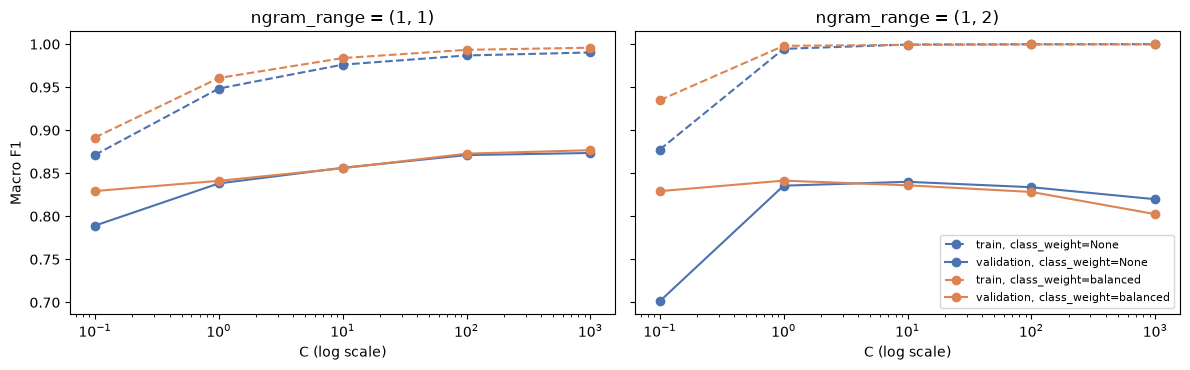

In [33]:
# Train vs cross-validation score across C: a widening gap means overfitting
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for i, ngram in enumerate(["(1, 1)", "(1, 2)"]):
    for bobot_kelas, warna in [("None", "#4C72B0"), ("balanced", "#DD8452")]:
        bagian = hasil_grid[(hasil_grid["ngram_range"] == ngram) & (hasil_grid["class_weight"] == bobot_kelas)].sort_values("C")
        nilai_c = bagian["C"].astype(float)
        ax[i].plot(nilai_c, bagian["Train macro F1"], "--o", color=warna, label=f"train, class_weight={bobot_kelas}")
        ax[i].plot(nilai_c, bagian["CV macro F1"], "-o", color=warna, label=f"validation, class_weight={bobot_kelas}")
    ax[i].set_xscale("log")
    ax[i].set_xlabel("C (log scale)")
    ax[i].set_title(f"ngram_range = {ngram}")
ax[0].set_ylabel("Macro F1")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [34]:
# Final check on the untouched test set: Scheme 2 as originally trained vs the tuned pipeline
model_svm_tuned = grid.best_estimator_
pred_awal = model_svm.predict(X_test_tfidf)
pred_tuned = model_svm_tuned.predict(X_test_2)

perbandingan = pd.DataFrame([
    {"Model": nama,
     "Accuracy": accuracy_score(y_test_2, pred),
     "Macro F1": f1_score(y_test_2, pred, average="macro"),
     "Neutral recall": recall_score(y_test_2, pred, labels=[LABEL_KE_ID["netral"]], average=None)[0]}
    for nama, pred in [("SVM + TF-IDF (Scheme 2, C=1, unigram)", pred_awal), ("SVM + TF-IDF (tuned)", pred_tuned)]
])
print(classification_report(y_test_2, pred_tuned, target_names=URUTAN_LABEL, digits=4))
perbandingan.round(4)

              precision    recall  f1-score   support

     negatif     0.9694    0.9761    0.9728      7535
      netral     0.7986    0.7425    0.7696      1239
     positif     0.9378    0.9477    0.9427      3326

    accuracy                         0.9444     12100
   macro avg     0.9019    0.8888    0.8950     12100
weighted avg     0.9432    0.9444    0.9437     12100



,Model,Accuracy,Macro F1,Neutral recall
0,"SVM + TF-IDF (Scheme 2, C=1, unigram)",0.9333,0.8614,0.5682
1,SVM + TF-IDF (tuned),0.9444,0.8950,0.7425


### Findings

- **Best configuration:** `C=1000`, unigrams, `class_weight="balanced"`, with a cross-validated macro F1 of about 0.877.
- **Unigrams: the score rises with `C` and then flattens.** Validation macro F1 goes from about 0.84 (`C=1`) to 0.856 (`C=10`), 0.872 (`C=100`), and 0.876
  (`C=1000`). The last step adds less than 0.005, so searching beyond 1000 is not worth the extra training time. At `C=0.1` the model underfits
  (0.79 without class weights).
- **Bigrams overfit.** They peak between `C=1` and `C=10` (about 0.84) and then decline to 0.80-0.82 at `C=1000` while the training score reaches 1.00.
  Bigrams add many features but no new information, because the labels were derived from single words.
- **Why so little regularization works here:** the labels come from a deterministic word-weight rule, so there is little label noise for
  regularization to protect against. A weakly regularized linear model on single words is close to the rule that generated the labels.
- **`class_weight` matters only at small `C`** (0.79 to 0.83 at `C=0.1`); at large `C` the two settings are nearly identical.
- **On the untouched test set**, accuracy improves from 93.3% to 94.4%, macro F1 from 0.861 to 0.895, and neutral recall from 0.57 to 0.74.
  The tuned SVM comes within about half a point of the BiLSTM (94.9%) while training in seconds.
- The gap between training and validation scores stays around 0.12 for every `C` of 1 or more, so the remaining errors are not something
  regularization can fix. They are the borderline reviews identified in the error analysis.
- The convergence warning above comes from the most extreme setting (bigrams, `C=1000`, balanced weights), which is also the worst-scoring one.
  The selected configuration converges without warnings.

The BiLSTM was not included in the search because each configuration takes minutes to train; early stopping and learning-rate
reduction already control its training length.

## 15. Interpretability and visualization

This section checks *what* the model pays attention to, using the tuned SVM because a linear model can be read directly:
the weight of every word for every class is available. Four views are shown: the most influential words per class,
LIME explanations for individual predictions, word clouds, and a t-SNE projection of the TF-IDF features.

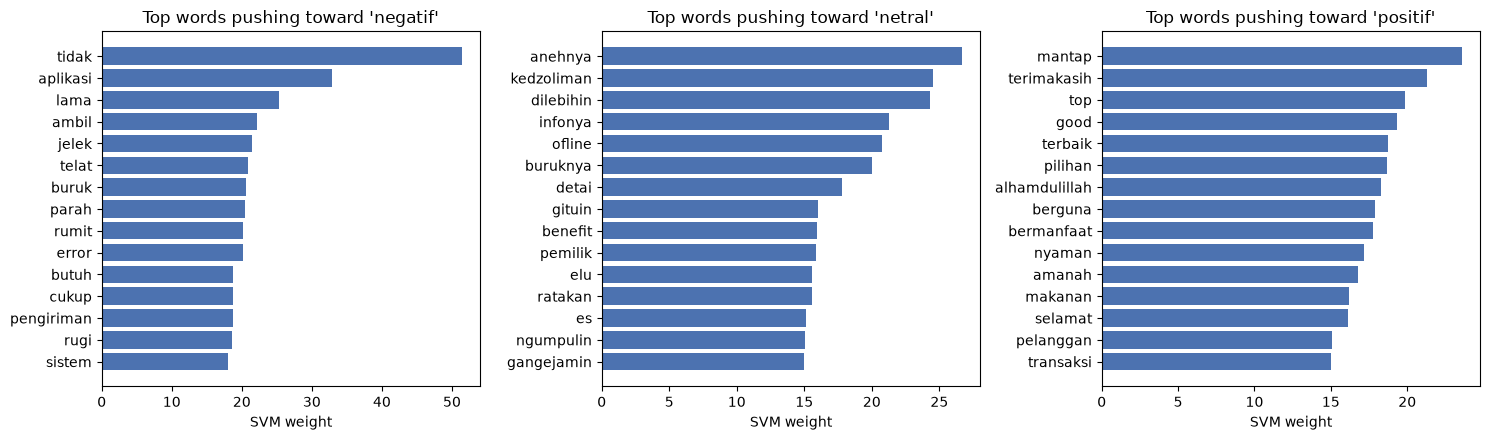

In [35]:
# Words (and bigrams) with the largest weights per class in the tuned SVM
fitur = model_svm_tuned.named_steps["tfidf"].get_feature_names_out()
koef = model_svm_tuned.named_steps["svm"].coef_

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for i, label in enumerate(URUTAN_LABEL):
    teratas = np.argsort(koef[i])[-15:]
    ax[i].barh(fitur[teratas], koef[i][teratas], color="#4C72B0")
    ax[i].set_title(f"Top words pushing toward '{label}'")
    ax[i].set_xlabel("SVM weight")
plt.tight_layout()
plt.show()

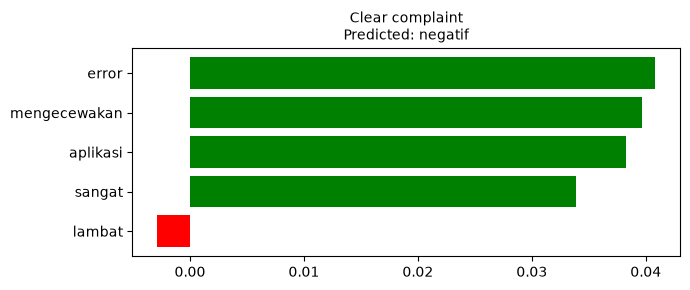

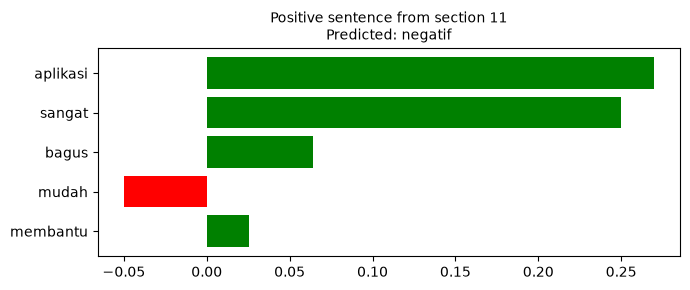

Raw review: perjalanan singkat namun punya kesan yang baik. meskipun menggunakan di saat orang pada lelap tidur namun bang drivernya tetap melayani dg baik dan ramah.


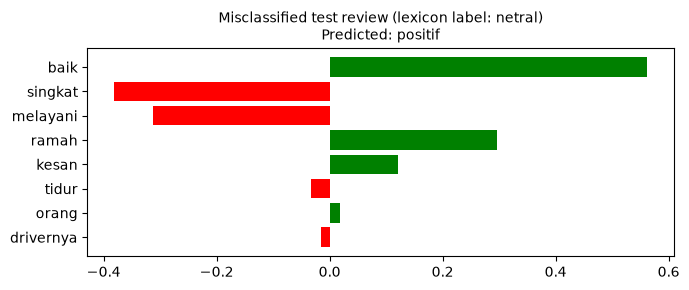

In [36]:
from lime.lime_text import LimeTextExplainer


def proba_svm(daftar_teks):
    """LinearSVC has no predict_proba, so its decision scores are turned into pseudo-probabilities with softmax."""
    skor = model_svm_tuned.decision_function(daftar_teks)
    eksp = np.exp(skor - skor.max(axis=1, keepdims=True))
    return eksp / eksp.sum(axis=1, keepdims=True)


penjelas = LimeTextExplainer(class_names=URUTAN_LABEL, split_expression=r"\s+", random_state=SEED)


def jelaskan(teks_mentah, judul):
    """Show which words push the tuned SVM toward (green) or away from (red) its predicted class."""
    teks = " ".join(preprocess(teks_mentah))
    prediksi = int(model_svm_tuned.predict([teks])[0])
    penjelasan = penjelas.explain_instance(teks, proba_svm, labels=[prediksi], num_features=8, num_samples=2000)
    fig = penjelasan.as_pyplot_figure(label=prediksi)
    fig.set_size_inches(7, 3)
    plt.title(f"{judul}\nPredicted: {ID_KE_LABEL[prediksi]}", fontsize=10)
    plt.tight_layout()
    plt.show()


# 1) A clear complaint, 2) the positive sentence from section 11 that the models call negative,
# 3) a medium-length test review that the tuned SVM itself misclassifies
jelaskan("Aplikasi sering error dan lambat, sangat mengecewakan", "Clear complaint")
jelaskan("Aplikasinya bagus banget, sangat membantu dan mudah digunakan", "Positive sentence from section 11")
salah_svm = err[(pred_tuned != y_test_2) & err["jumlah_kata"].between(5, 15)]
contoh_salah = salah_svm.sample(1, random_state=SEED).iloc[0]
print("Raw review:", contoh_salah["content"])
jelaskan(contoh_salah["content"], f"Misclassified test review (lexicon label: {contoh_salah['actual']})")

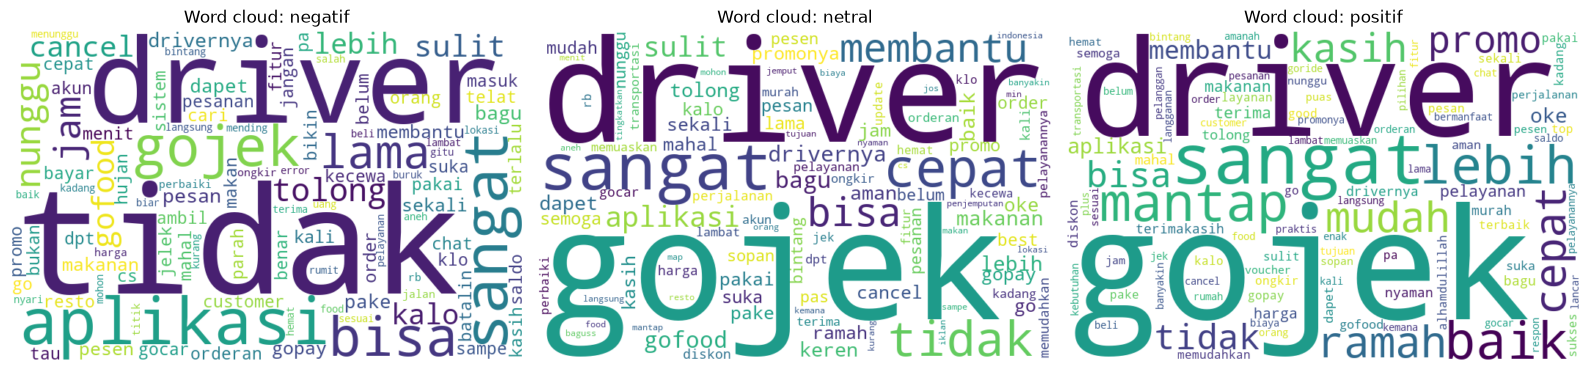

In [37]:
from wordcloud import WordCloud

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for i, label in enumerate(URUTAN_LABEL):
    teks = " ".join(df.loc[df["label"] == label, "text_akhir"])
    awan = WordCloud(width=700, height=450, background_color="white", collocations=False,
                     max_words=100, random_state=SEED).generate(teks)
    ax[i].imshow(awan, interpolation="bilinear")
    ax[i].set_title(f"Word cloud: {label}")
    ax[i].axis("off")
plt.tight_layout()
plt.show()

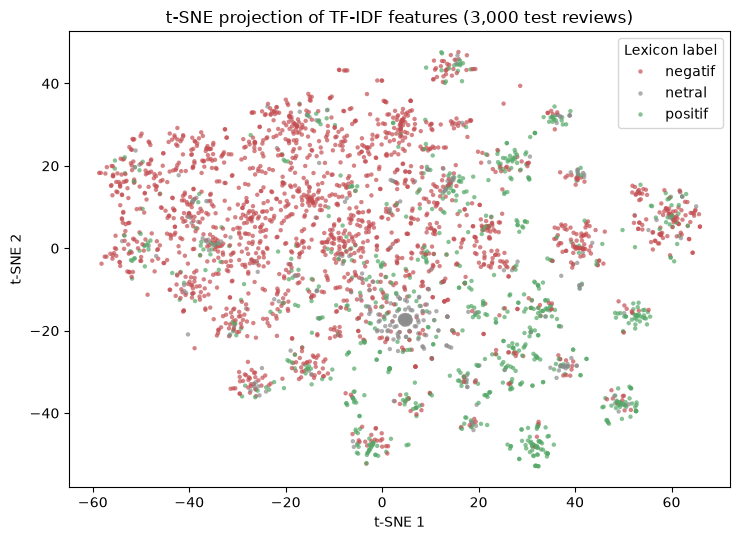

In [38]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# t-SNE is slow on tens of thousands of points, so a random sample of the test set is projected.
# TF-IDF vectors are first reduced to 50 dimensions with SVD, then to 2 with t-SNE.
rng_np = np.random.default_rng(SEED)
sampel = rng_np.choice(len(X_test_2), size=3000, replace=False)
vektor_sampel = model_svm_tuned.named_steps["tfidf"].transform(X_test_2[sampel])
proyeksi = TSNE(n_components=2, random_state=SEED, init="pca").fit_transform(
    TruncatedSVD(n_components=50, random_state=SEED).fit_transform(vektor_sampel))

plt.figure(figsize=(7.5, 5.5))
sns.scatterplot(x=proyeksi[:, 0], y=proyeksi[:, 1], hue=[ID_KE_LABEL[i] for i in y_test_2[sampel]],
                hue_order=URUTAN_LABEL, palette={"negatif": "#C44E52", "netral": "#8C8C8C", "positif": "#55A868"},
                s=10, alpha=0.7, linewidth=0)
plt.title("t-SNE projection of TF-IDF features (3,000 test reviews)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Lexicon label")
plt.tight_layout()
plt.show()

### Findings

- **Feature weights.** The strongest positive words (`mantap`, `terimakasih`, `top`, `terbaik`) and most negative words (`tidak`, `lama`, `jelek`, `telat`, `error`)
  make sense. Two things do not: `aplikasi` ("app"), a neutral word, carries one of the largest negative weights, inherited from the lexicon;
  and the neutral class is driven by rare words (`anehnya`, `dilebihin`, `infonya`), which means the model memorizes individual neutral reviews
  instead of learning a general pattern.
- **LIME.** For the clear complaint, `error` and `mengecewakan` ("disappointing") drive the negative prediction, which is the right reason.
  For the positive sentence from section 11, `aplikasi` and `sangat` push hardest toward negative and even `bagus` ("good") pushes the same way, confirming
  that the wrong prediction comes from the lexicon weights rather than from a modeling error. The "misclassified" test review praises a driver as
  `baik` ("kind") and `ramah` ("friendly"); the model predicts positive, which a human reader would agree with, but the lexicon labeled it neutral.
  Here the model is arguably right and the label is wrong.
- **Word clouds.** `driver` and `gojek` dominate all three classes: the most frequent words describe the topic, not the sentiment.
  The negative cloud is distinguished mainly by `tidak` ("not"), the positive one by `mantap`, `baik`, `ramah`, and `cepat`.
- **t-SNE.** Negative reviews fill the largest region, positive reviews form small clusters toward the edges, and neutral reviews are
  scattered across both with almost no region of their own. This matches the error analysis: the neutral class is the hardest to separate.

## 16. Generating requirements.txt

This file records the versions of the libraries actually used when the notebook was run.

In [39]:
from importlib.metadata import PackageNotFoundError, version

PAKET = ["google-play-scraper", "pandas", "numpy", "nltk", "scikit-learn",
         "tensorflow", "matplotlib", "seaborn", "requests"]

baris = []
for nama in PAKET:
    try:
        baris.append(f"{nama}=={version(nama)}")
    except PackageNotFoundError:
        baris.append(nama)

with open("requirements.txt", "w") as f:
    f.write("\n".join(baris) + "\n")
print("\n".join(baris))

google-play-scraper
pandas==3.0.6
numpy==2.5.3
nltk==3.10.3
scikit-learn==1.9.1
tensorflow==2.21.0
matplotlib==3.11.2
seaborn==0.13.2
requests==2.34.2


In [40]:
# Libraries added in sections 13-15
PAKET_TAMBAHAN = ["Sastrawi", "lime", "wordcloud"]

with open("requirements.txt", "a") as f:
    for nama in PAKET_TAMBAHAN:
        try:
            baris_baru = f"{nama}=={version(nama)}"
        except PackageNotFoundError:
            baris_baru = nama
        f.write(baris_baru + "\n")
        print(baris_baru)

Sastrawi==1.0.1
lime==0.2.0.1
wordcloud==1.9.6
